# Phase 3.5+ : Python 因果推断库实战 (DoWhy) 🛡️

> **🎯 目标**: 告别手写罗辑回归，使用微软的 `DoWhy` 库进行标准化的因果推断。
> **关键点**: **Refutation (反驳)** —— 这是你在汇报时面对质疑的底气。

## 🧠 为什么不用手写代码？
之前的 PSM 我们是手写的 (LogisticRegression -> predict)。但在复杂场景下，我们需要一个框架来帮我们管理：
1.  **Causal Graph**: 画出因果图，明确谁是干扰项 (Common Cause)。
2.  **Identification**: 自动识别能不能算（是不是有未观测的混杂？）。
3.  **Estimation**: 自动跑模型。
4.  **Refutation (最重要)**: 自动做敏感性测试（比如：如果我加一个随机变量，结果会变吗？如果变了，说明你的模型是瞎蒙的）。

---
### 0. 安装环境
如果你没有安装 dowhy，请运行下面的命令：

In [ ]:
# 在 Jupyter 中，推荐使用 %pip 魔法命令，它会自动安装到当前内核
# 如果你在终端运行，Mac 用户通常需要用 'pip3 install dowhy'
# %pip install dowhy

In [1]:
import numpy as np
import pandas as pd
import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore') # 屏蔽一些烦人的 warning

# 1. 造数据 (Mock Data)
# 这次我们模拟一个 "看书时长(Reading)" 对 "考试成绩(Score)" 的影响
# 混杂因素(Confounder): 智商(IQ)。智商高的人既爱看书，成绩又好。
np.random.seed(42)
n = 1000

iq = np.random.normal(100, 15, n) # Confounder
reading_hours = 0.5 * iq + np.random.normal(0, 10, n) # Treatment (受 IQ 影响)
score = 0.3 * reading_hours + 0.6 * iq + np.random.normal(0, 5, n) # Outcome
# 真实因果效应 (True Loop): 0.3 (看书对成绩的直接提升)
# 如果直接跑回归: Score ~ Reading，系数会远大于 0.3 (因为混入了 IQ 的作用)

df = pd.DataFrame({'IQ': iq, 'Reading': reading_hours, 'Score': score})
print(df.head())

./Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


           IQ    Reading      Score
0  107.450712  67.718911  81.410209
1   97.926035  58.209355  75.495834
2  109.715328  55.453968  78.503288
3  122.845448  54.953356  88.653468
4   96.487699  55.226083  64.992371


## Step 1: Model (画因果图)
告诉由 DoWhy，我们要研究谁对谁的影响，以及你要控制谁。

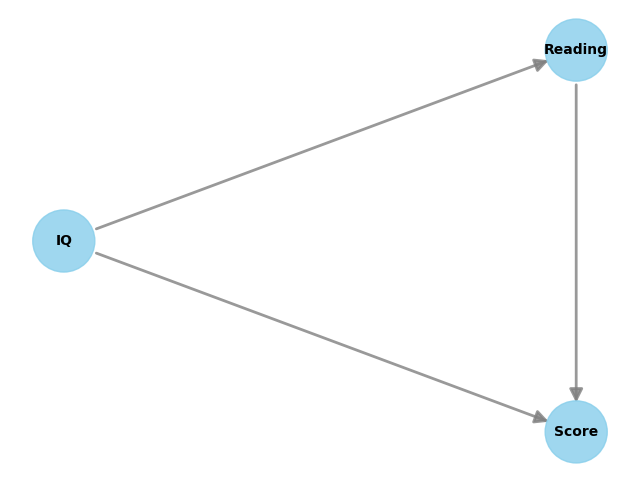

In [2]:
model = CausalModel(
    data=df,
    treatment='Reading',
    outcome='Score',
    common_causes=['IQ'] # 告诉它，IQ 是混杂因素
)

# 画出来看看
model.view_model()

## Step 2: Identify (识别)
DoWhy 会自动分析：在这个图结构下，能不能算出因果效应？用什么方法算？(比如 Backdoor Criterion)

In [3]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                  
──────────(E[Score|IQ])
d[Reading]             
Estimand assumption 1, Unconfoundedness: If U→{Reading} and U→Score then P(Score|Reading,IQ,U) = P(Score|Reading,IQ)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



## Step 3: Estimate (估算)
真正的计算来了。我们会用线性回归的方法来“控制”IQ。

In [4]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(f"Causal Estimate: {estimate.value}")
print(f"True Effect: 0.3")
# 看看它是不是接近 0.3？

Causal Estimate: 0.29491132893765837
True Effect: 0.3


## Step 4: Refute (反驳/压力测试) 🛡️
**这是 Senior 必做的一步！**
我们在这个模型里搞点破坏，看看结果会不会崩。

### Test 1: Placebo Treatment (安慰剂检验)
如果我们把 "读书时长" 换成一个随机生成的假变量，结果应该变成多少？
*   **预期**: 结果应该是 **0**。
*   **实际**: 如果跑出来不是 0，说明你的模型代码写错了，或者数据有严重的泄露。

In [5]:
refutation = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter"
)

print(refutation)

Refute: Use a Placebo Treatment
Estimated effect:0.29491132893765837
New effect:0.0
p value:1.0



### Test 2: Add Random Common Cause (加个随机干扰项)
如果我在数据里加一列完全随机的数，声称它也是混杂因素，结果会变吗？
*   **预期**: 结果即不应该变 (Estimate should not change)。
*   **含义**: 你的模型足够“鲁棒” (Robust)，不会被噪音带偏。

In [6]:
refutation_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)

print(refutation_random)

Refute: Add a random common cause
Estimated effect:0.29491132893765837
New effect:0.29491547419097636
p value:0.96

